2.7 Simulation de processus

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1. Trajectoires de Poisson

Construire une fonction prenant en entrée une intensité \(\lambda > 0\) et un entier \(n\), et renvoyant les \(n\) premiers temps de saut d’un processus de Poisson d’intensité \(\lambda\).
Tracer une trajectoire (par exemple avec la fonction `step` de `pyplot`).
Pour tout réel \(t > 0\), renvoyer la valeur de \(N_t\).
Calculer un estimateur de \(\lambda\).

Input: namda, n

Output: ( T1, T2, ... , Tn), trajectoire, Nt,

In [ ]:
def poisson_n_jump(lam, n):
    # 1) generate first n jump times
    inter = np.random.exponential(scale=1/lam, size=n)   # Exp(rate=lam)
    T = np.cumsum(inter)                                  # jump times T1..Tn

    # choose horizon for plot/estimation: T_end = T_n
    T_end = float(T[-1])

    # 2) define N_t(t): number of jumps <= t
    def Nt(t):
        t = float(t)
        if t < 0:
            raise ValueError("t must be >= 0")
        return int(np.searchsorted(T, t, side="right"))

    # 3) plot trajectory N_t on [0, T_end]
    t_points = np.r_[0.0, T, T_end]
    n_points = np.r_[0, np.arange(1, n + 1), n]

    plt.figure()
    plt.step(t_points, n_points, where="post")
    plt.xlabel("t")
    plt.ylabel("N_t")
    plt.title(f"Poisson process trajectory (lambda={lam})")
    plt.grid(True)
    plt.show()

    # 4) lambda estimate: \hat{lambda} = N_T / T with T = T_end, N_T = n
    lam_hat = n / T_end

    return T, Nt, lam_hat

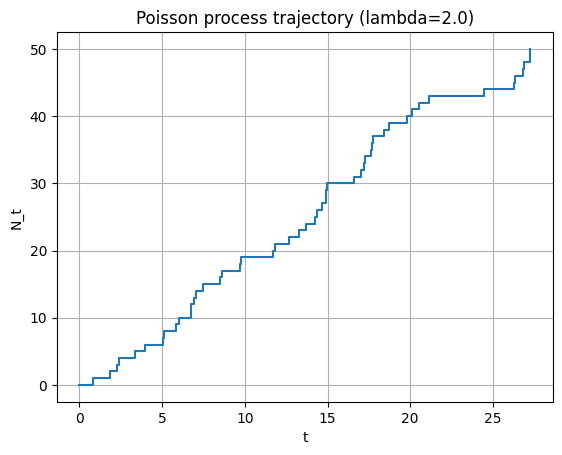

first 5 jump times: [0.79039126 1.87031504 2.27577288 2.37947641 3.36606948]
N_3.7 = 5
lambda_hat = 1.833798344266978


In [ ]:
T, Nt, lam_hat = poisson_n_jump(lam=2.0, n=50)

print("first 5 jump times:", T[:5])
print("N_3.7 =", Nt(3.7))
print("lambda_hat =", lam_hat)

2. Trajectoires de Poisson

Construire une fonction prenant en entrée une intensité \(\lambda > 0\) et un réel \(T > 0\), et renvoyant une trajectoire d’un processus de Poisson d’intensité \(\lambda\) sur l’intervalle \([0,T]\).
Tracer cette trajectoire.


In [ ]:
def poisson_T_time(lam, T):
    n = np.random.poisson(lam * T)
    jump_times = np.sort(np.random.uniform(0.0, T, size=n)) if n > 0 else np.array([])

    t_points = np.r_[0.0, jump_times, T]
    N_points = np.r_[0, np.arange(1, n + 1), n]

    plt.step(t_points, N_points, where="post")
    plt.xlabel("t"); plt.ylabel("N_t")
    plt.title(f"Poisson process on [0,{T}] (lambda={lam})")
    plt.grid(True); plt.show()

    N_T = n
    lam_hat = N_T / T
    return jump_times, N_T, lam_hat

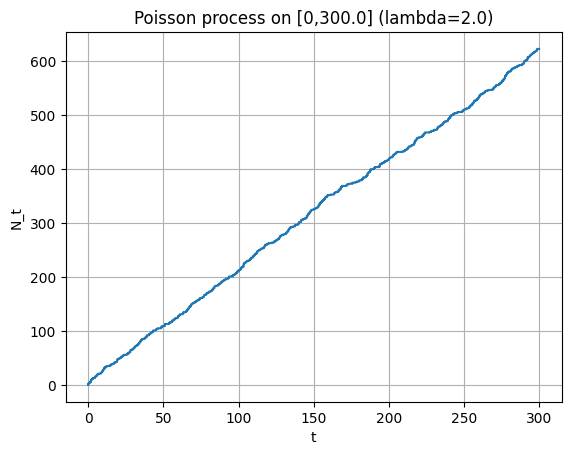

jump times: [5.57492578e-02 6.05087358e-02 2.81810625e-01 4.68382793e-01
 1.38852671e+00 1.55291227e+00 1.65407696e+00 1.67137100e+00
 2.08176923e+00 2.12595331e+00 2.42590532e+00 3.03072495e+00
 3.41078704e+00 4.51710530e+00 4.65903353e+00 4.83656560e+00
 5.24844049e+00 5.75997065e+00 6.12316039e+00 6.16697080e+00
 7.05135629e+00 8.42594202e+00 8.57233077e+00 9.07967629e+00
 9.17489752e+00 9.67580477e+00 9.72763474e+00 9.92114022e+00
 1.01358098e+01 1.06718576e+01 1.06822018e+01 1.08258574e+01
 1.10382035e+01 1.19929089e+01 1.22159775e+01 1.42765635e+01
 1.49702028e+01 1.51413123e+01 1.60833030e+01 1.71759458e+01
 1.72055951e+01 1.76690644e+01 1.86919039e+01 1.90997041e+01
 1.93057492e+01 1.93231388e+01 1.93330100e+01 1.96066870e+01
 2.02212829e+01 2.11163534e+01 2.19878203e+01 2.20382609e+01
 2.22230169e+01 2.31599515e+01 2.32241547e+01 2.40648924e+01
 2.57256408e+01 2.64080241e+01 2.64884992e+01 2.67245440e+01
 2.76596540e+01 2.80383846e+01 2.80389102e+01 2.80418595e+01
 2.83333791e

In [ ]:
jump_times, N_T, lam_hat = poisson_T_time(lam=2.0, T=300.0)

print("jump times:", jump_times)
print("N_T:", N_T)
print("lambda_hat:", lam_hat)

3. Observations discrètes

Pour \(T > \Delta > 0\), renvoyer les valeurs observées de \(N\) aux instants \(i\Delta\).
Tracer sur une même figure la trajectoire continue et les points d’observation discrets.

In [ ]:
def observe_on_grid(jump_times, T, Delta):
    # grid times: 0, Δ, 2Δ, ..., <= T
    t_grid = np.arange(0.0, T + 1e-12, Delta)

    # N_{t} = number of jump times <= t  (vectorized)
    N_grid = np.searchsorted(jump_times, t_grid, side="right")

    # continuous trajectory (for plotting)
    n = len(jump_times)
    t_points = np.r_[0.0, jump_times, T]
    N_points = np.r_[0, np.arange(1, n + 1), n]

    # plot both on same figure
    plt.figure()
    plt.step(t_points, N_points, where="post", label="continuous trajectory")
    plt.scatter(t_grid, N_grid, s=15, label="discrete observations (iΔ)")
    plt.xlabel("t"); plt.ylabel("N_t")
    plt.title(f"Continuous path + discrete observations (Δ={Delta})")
    plt.grid(True); plt.legend()
    plt.show()

    return t_grid, N_grid

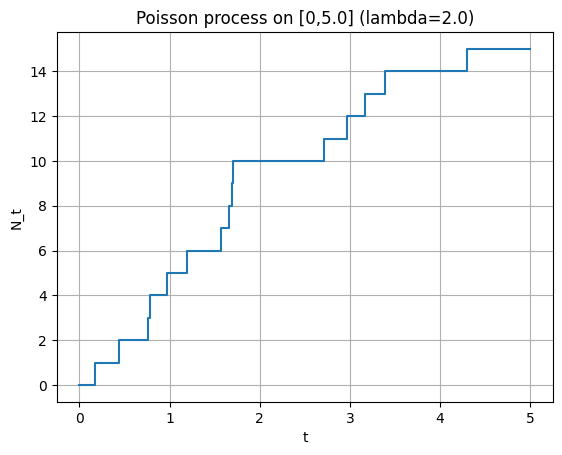

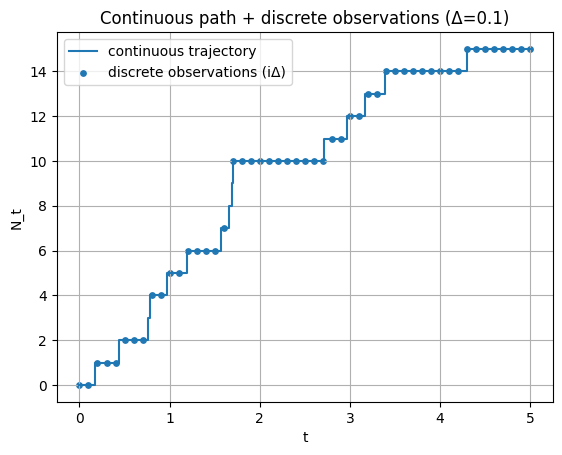

t_grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9] ...
N_grid: [0 0 1 1 1 2 2 2 4 4] ...
 Δ the delta overhere should be more frequent than the jump, so that we can observe the jump


In [ ]:
jump_times, N_T, lam_hat = poisson_T_time(lam=2.0, T=5.0)

t_grid, N_grid = observe_on_grid(jump_times, T=5.0, Delta=0.1)

print("t_grid:", t_grid[:10], "...")
print("N_grid:", N_grid[:10], "...")
print(" Δ the delta overhere should be more frequent than the jump, so that we can observe the jump")

4. Processus de renouvellement

Pour adapter le code précédent au cas d’un processus de renouvellement, que faut-il modifier ?


Oui. Il suffit de modifier la partie qui génère les temps inter-arrivées dans le code (par ex. dans la Q1) : remplacer  
`inter = np.random.exponential(scale=1/lam, size=...)`  
par un tirage i.i.d. selon une loi plus générale \(F\) (Gamma, Weibull, log-normale, constante, etc.).  
Le reste (cumul `cumsum` pour obtenir \(T_k\), tracé en `step`, calcul de \(N_t\) par comptage) reste inchangé.

5. Trajectoires de Poisson inhomogène

Simuler un processus de Poisson inhomogène de fonction d’intensité \(\lambda_0(u)=1+\sin(u)\) sur \([0,10]\).

Nt doesn't follow  $\mathrm{Poisson}(\lambda t)$，but

$$
N_t \sim \mathrm{Poisson}\!\left(\int_0^t \lambda(u)\,du\right).
$$

Here, $\lambda(u)=1+\sin(u)$：

$$
\int_0^t (1+\sin u)\,du = t + (1-\cos t).
$$

so

$$
N_t \sim \mathrm{Poisson}\!\big(t+1-\cos t\big).
$$


In [ ]:
# thinning
def nhpp_sin(T=10.0):
    lam = lambda t: 1.0 + np.sin(t)   # intensity function
    M = 2.0                           # global upper bound since 1+sin(t) <= 2 on all t

    t = 0.0
    jump_times = []

    while True:
        # propose next event time from homogeneous Poisson with rate M
        t += np.random.exponential(scale=1.0 / M)
        if t > T:
            break

        # accept with probability lam(t)/M
        if np.random.rand() <= lam(t) / M:
            jump_times.append(t)

    jump_times = np.array(jump_times)

    # plot N_t on [0, T]
    n = len(jump_times)
    t_points = np.r_[0.0, jump_times, T]
    N_points = np.r_[0, np.arange(1, n + 1), n]

    plt.step(t_points, N_points, where="post")
    plt.xlabel("t"); plt.ylabel("N_t")
    plt.title("Inhomogeneous Poisson: λ(t)=1+sin(t) on [0,10]")
    plt.grid(True); plt.show()

    return jump_times

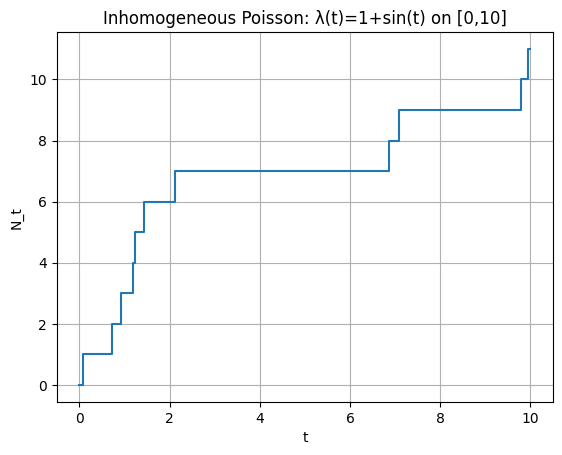

jump times: [0.08215416 0.72884272 0.91205626 1.17948439 1.24171406 1.42351393
 2.12224501 6.85400661 7.09778285 9.78493196 9.9379122 ]
N_T: 11


In [ ]:
jump_times = nhpp_sin(T=10.0)
print("jump times:", jump_times)
print("N_T:", len(jump_times))

## thinning 的核心思想

1. **先用更快的“候选过程”生成事件**  
   生成一个**齐次泊松过程**（常强度）速率 \(M\)，它比真实过程“更密”。  
   实现方式：不断抽指数等待时间 \(\mathrm{Exp}(M)\)。

2. **再把候选事件按概率删掉（稀释）**  
   在候选时刻 \(t\)，真实过程的强度是 \(\lambda(t)\)。  
   接受这个事件的概率设为：
   \[
   p(t)=\frac{\lambda(t)}{M}\in[0,1].
   \]
   - 若 \(U \le p(t)\)（\(U\sim \mathcal{U}[0,1]\)），就保留该事件；
   - 否则删掉。

3. **保留下来的事件时刻，就是目标非齐次泊松过程的跳时。**

4. **最后用 `jump_times` 画阶梯函数 \(N_t\)。**

## Summary

This notebook illustrates three complementary simulation mechanisms:

- exponential inter-arrival times for a homogeneous Poisson process;
- replacement of the exponential law to obtain a renewal process;
- thinning of a dominating homogeneous process for the non-homogeneous intensity
  $\lambda(t)=1+\sin(t)$.

The simulations also recover the expected counting-rate behavior: $N_T/T$ estimates
the homogeneous intensity, while the non-homogeneous count has mean
$\int_0^T\lambda(u)\,du=T+1-\cos(T)$.
